In [26]:
# author: Suhas Vittal
#
# Plots for CaT (out/oclk_micro2026). Run from the repo's `scripts/` directory.

import sys, os
sys.path.insert(0, 'scripts')

from plotting_util import *
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

# colors (shared with plotting.ipynb)
C1 = '#f0f9e8'
C2 = '#bae4bc'
C3 = '#7bccc4'
C4 = '#43a2ca'
C5 = '#0868ac'

STATS_FOLDER = '../out/oclk_micro2026/simulation_results'
PLOT_FOLDER  = 'plots/oclk'
os.makedirs(PLOT_FOLDER, exist_ok=True)

# 5 workloads (file basenames) and how they appear on the x-axis
WORKLOADS = ['BQ_shor_rsa256_iter_4',
             'BQ_grover_3sat_schoning_1710',
             'BQ_chromium_t',
             'BQ_c2h4o_ethylene_oxide_t',
             'BQ_hc3h2cn_t']
TICKS = ['shor_rsa256', 'grover_3sat', 'chromium', 'ethylene', 'hc3h2cn']

# systems and the magic-state footprint budgets
SYS        = ['A', 'B', 'C', 'D']
SYS_COLORS = [C1, C2, C3, C4]
MSF        = [2500, 5000, 7500, 10000]   # 5000 == the no-suffix default dirs

# speedup is computed from KIPS (instruction counts are identical across configs,
# so CaT_KIPS / baseline_KIPS == baseline_cycles / cat_cycles).
STAT_KEY = 'CLIENT 0/KIPS'

In [27]:
# --- plotting helpers ---

def _nested_dict_access(stats: dict, key: str):
    '''Access `stats` by a '/'-separated key path, e.g. 'CLIENT 0/KIPS'.'''
    parts = key.split('/')
    d = stats
    for p in parts:
        if p not in d:
            print(f'dictionary does not have index {p}:', d.keys())
        d = d[p]
    return d


def speedup_pct(cat_cfg, base_cfg, append_gmean=True):
    '''Per-workload % speedup of `cat_cfg` over `base_cfg` (each a workload->stats
    dict from aggregate_stats_by_policy). Returns (CaT/baseline - 1) * 100 for each
    workload in WORKLOADS, optionally with a trailing geomean entry.'''
    ratios = [float(_nested_dict_access(cat_cfg[w], STAT_KEY))
              / float(_nested_dict_access(base_cfg[w], STAT_KEY))
              for w in WORKLOADS]
    if append_gmean:
        ratios.append(sp.stats.gmean(ratios))
    return (np.array(ratios) - 1) * 100


def grouped_bars(ax, xticklabels, series, ylabel, xlabel=None, rotate_xticks=True):
    '''Generic grouped bar chart.
    `series`: list of (label, color, Y) where Y is a % array aligned to `xticklabels`.'''
    ax.set_ylabel(ylabel, fontsize=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12)

    n = len(series)
    x = np.arange(len(xticklabels))
    width = 1.0 / (n + 1)
    for (i, (label, color, Y)) in enumerate(series):
        print(label, Y)
        ax.bar(x + i * width, Y, width, color=color, edgecolor='k', zorder=3, label=label)

    if rotate_xticks:
        ax.set_xticks(x + (n - 1) / 2 * width, xticklabels, rotation=30, ha='right', fontsize=10)
    else:
        ax.set_xticks(x + (n - 1) / 2 * width, xticklabels, fontsize=10)
    ax.grid(visible=True, axis='y', zorder=0)
    ax.legend(fontsize=10, ncol=n, loc='lower center', bbox_to_anchor=(0.5, 1.0), framealpha=1.0)

Sys A [7.64025108 7.585942   6.65409483 7.2725526  7.28885461 7.28776479]
Sys B [9.02824479 8.95473251 7.85098522 8.58036891 8.59362089 8.60078704]
Sys C [12.40148793 12.30246914 10.73325635 11.77124506 11.80043384 11.80020576]
Sys D [28.30212471 28.00617284 23.91454965 26.52544466 26.59436009 26.65894285]


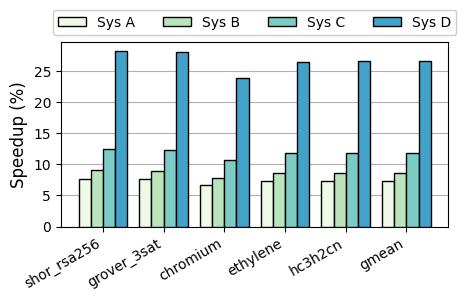

In [28]:
'''
    PLOT 1: CaT speedup over baseline per workload, for systems A/B/C/D.
    (default magic-state footprint, memory config)
    Each system's CaT is normalized to the baseline on the SAME system.
'''

series = []
for (s, color) in zip(SYS, SYS_COLORS):
    base = aggregate_stats_by_policy(f'{STATS_FOLDER}/baseline_sys{s}')
    cat  = aggregate_stats_by_policy(f'{STATS_FOLDER}/cat_sys{s}')
    series.append((f'Sys {s}', color, speedup_pct(cat, base)))

fig, ax = plt.subplots()
fig.set_size_inches(5.0, 2.4)
grouped_bars(ax, TICKS + ['gmean'], series, 'Speedup (%)')
plt.savefig(f'{PLOT_FOLDER}/oclk_speedup.pdf', bbox_inches='tight')

Sys A [7.53647476 7.28776479 6.89560795 6.16911525]
Sys B [8.88993423 8.60078704 8.13268348 7.24771523]
Sys C [12.23099004 11.80020576 11.11906486  9.81687955]
Sys D [27.85044816 26.65894285 24.65929179 20.68122573]


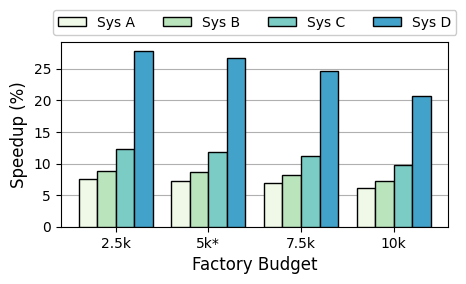

In [29]:
'''
    PLOT 2: gmean CaT speedup vs magic-state footprint budget, one series per
    system. Each CaT config is normalized to the baseline on the SAME system at
    the SAME footprint budget.
'''

def _bdir(s, b):
    return f'baseline_sys{s}' if b == 5000 else f'baseline_sys{s}_msf{b}'

def _cdir(s, b):
    return f'cat_sys{s}' if b == 5000 else f'cat_sys{s}_msf{b}'

def _msf_label(b):
    # 2500 -> '2.5k', 5000 -> '5k*' (the baseline/default budget), etc.
    s = f'{b / 1000:g}k'
    return s + '*' if b == 5000 else s

series = []
for (s, color) in zip(SYS, SYS_COLORS):
    Y = []
    for b in MSF:
        base = aggregate_stats_by_policy(f'{STATS_FOLDER}/{_bdir(s, b)}')
        cat  = aggregate_stats_by_policy(f'{STATS_FOLDER}/{_cdir(s, b)}')
        # speedup_pct already returns gmean as its trailing entry
        Y.append(speedup_pct(cat, base)[-1])
    series.append((f'Sys {s}', color, np.array(Y)))

fig, ax = plt.subplots()
fig.set_size_inches(5.0, 2.4)
grouped_bars(ax, [_msf_label(b) for b in MSF], series, 'Speedup (%)',
             xlabel='Factory Budget', rotate_xticks=False)
plt.savefig(f'{PLOT_FOLDER}/oclk_msf_sensitivity.pdf', bbox_inches='tight')

Sys A [7.66444792 7.66730402 7.02916631 7.3536434  7.35590294 7.41383023]
Sys B [9.06192314 9.06260243 8.28908555 8.6935167  8.69779678 8.76060511]
Sys C [12.45988295 12.46389282 11.34892982 11.90987783 11.92428633 12.02060359]
Sys D [28.47523756 28.49855571 25.4466014  26.88931181 26.91904556 27.24059258]


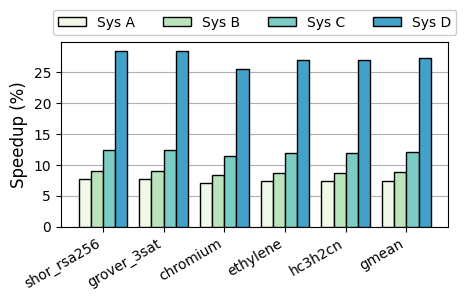

In [30]:
'''
    PLOT 3: CaT speedup over baseline per workload, for systems A/B/C/D,
    for the NOMEM configuration.
    Each system's CaT is normalized to the baseline on the SAME system.
'''

series = []
for (s, color) in zip(SYS, SYS_COLORS):
    base = aggregate_stats_by_policy(f'{STATS_FOLDER}/baseline_sys{s}_nomem')
    cat  = aggregate_stats_by_policy(f'{STATS_FOLDER}/cat_sys{s}_nomem')
    series.append((f'Sys {s}', color, speedup_pct(cat, base)))

fig, ax = plt.subplots()
fig.set_size_inches(5.0, 2.4)
grouped_bars(ax, TICKS + ['gmean'], series, 'Speedup (%)')
plt.savefig(f'{PLOT_FOLDER}/oclk_speedup_nomem.pdf', bbox_inches='tight')